# Решение соревнования с Kaggle "G-Research Crypto Forecasting'
В данном соревновании ставится задача предсказания будущей доходности актива. В рамках обработки временных рядов я использовал нейронную сеть LSTM, работающую с последовательностю значений временного ряда.

Автор: Потапов Иван

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crypto-time-series/example_sample_submission.csv
/kaggle/input/crypto-time-series/asset_details.csv
/kaggle/input/crypto-time-series/example_test.csv
/kaggle/input/crypto-time-series/train.csv
/kaggle/input/crypto-time-series/supplemental_train.csv


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
train_df = pd.read_csv("/kaggle/input/crypto-time-series/train.csv")
asset_df = pd.read_csv("/kaggle/input/crypto-time-series/asset_details.csv")
sample_sub = pd.read_csv("/kaggle/input/crypto-time-series/example_sample_submission.csv")



In [ ]:
supp_df = pd.read_csv('/kaggle/input/crypto-time-series/supplemental_train.csv')

In [ ]:
full = pd.concat([train_df, supp_df], ignore_index=True)
full = full.merge(asset_df[["Asset_ID","Weight"]], on="Asset_ID", how="left")
full = full.sort_values(["Asset_ID","timestamp"]).reset_index(drop=True)

In [ ]:
print("full:", full.shape, "target NaNs:", full["Target"].isna().mean())

full: (26755084, 11) target NaNs: 0.028153938892511044


In [ ]:
asset_details = pd.read_csv("/kaggle/input/crypto-time-series/asset_details.csv")

In [ ]:
unique_ids = crypto_df.iloc[:, 1].unique()
print(unique_ids)

[ 2  0  1  5  7  6  9 11 13 12  3  8 10  4]


In [ ]:
filtered = asset_details[asset_details["Asset_ID"].isin(unique_ids)]
id2name = filtered.set_index("Asset_ID")["Asset_Name"].to_dict()

In [ ]:
btc = crypto_df[crypto_df["Asset_ID"]==1].set_index("timestamp") # Asset_ID = 1 for Bitcoin
btc_mini = btc.iloc[-200:]

In [ ]:
btc_mini

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Asset_ID,Count,Open,High,Low,Close,Volume,VWAP,Target
timestamp,,,,,,,,,
1632170460,1,5694.0,43558.393750,43588.680000,43427.28,43447.003750,191.442881,43493.981877,-0.000805
1632170520,1,2528.0,43449.818571,43495.954028,43414.33,43440.000000,80.692018,43455.988146,0.000418
1632170580,1,3985.0,43427.082310,43455.218478,43327.29,43360.723750,117.332513,43391.956795,0.000125
1632170640,1,2185.0,43362.572857,43454.990000,43348.06,43427.242857,76.361478,43403.880056,0.000956
1632170700,1,2623.0,43419.832500,43467.000000,43351.15,43375.040000,76.018320,43408.267118,-0.000430
...,...,...,...,...,...,...,...,...,...
1632182160,1,1940.0,42983.780000,43001.850849,42878.26,42899.012857,56.850913,42935.489499,NaN
1632182220,1,2026.0,42904.197143,42932.000000,42840.16,42860.005714,80.993326,42879.576084,NaN
1632182280,1,1986.0,42859.385714,42887.500000,42797.20,42827.020000,65.677734,42844.090693,NaN


In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x=btc_mini.index, open=btc_mini['Open'], high=btc_mini['High'], low=btc_mini['Low'], close=btc_mini['Close'])])
fig.show()

In [ ]:
eth = crypto_df[crypto_df["Asset_ID"]==6].set_index("timestamp") # Asset_ID = 6 for Ethereum
eth.info(show_counts =True)

<class 'pandas.core.frame.DataFrame'>
Index: 1956200 entries, 1514764860 to 1632182400
Data columns (total 9 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   Asset_ID  1956200 non-null  int64  
 1   Count     1956200 non-null  float64
 2   Open      1956200 non-null  float64
 3   High      1956200 non-null  float64
 4   Low       1956200 non-null  float64
 5   Close     1956200 non-null  float64
 6   Volume    1956200 non-null  float64
 7   VWAP      1956200 non-null  float64
 8   Target    1955860 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 149.2 MB


In [ ]:
eth.isna().sum()

Asset_ID      0
Count         0
Open          0
High          0
Low           0
Close         0
Volume        0
VWAP          0
Target      340
dtype: int64

In [ ]:
btc.head()

,Asset_ID,Count,Open,High,Low,Close,Volume,VWAP,Target
timestamp,,,,,,,,,
1514764860,1,229.0,13835.194,14013.8,13666.11,13850.176,31.550062,13827.062093,-0.014643
1514764920,1,235.0,13835.036,14052.3,13680.00,13828.102,31.046432,13840.362591,-0.015037
1514764980,1,528.0,13823.900,14000.4,13601.00,13801.314,55.061820,13806.068014,-0.010309
1514765040,1,435.0,13802.512,13999.0,13576.28,13768.040,38.780529,13783.598101,-0.008999
1514765100,1,742.0,13766.000,13955.9,13554.44,13724.914,108.501637,13735.586842,-0.008079


In [ ]:
eth = eth.reindex(range(eth.index[0],eth.index[-1]+60,60),method='pad')
(eth.index[1:]-eth.index[:-1]).value_counts().head()

timestamp
60    1956959
Name: count, dtype: int64

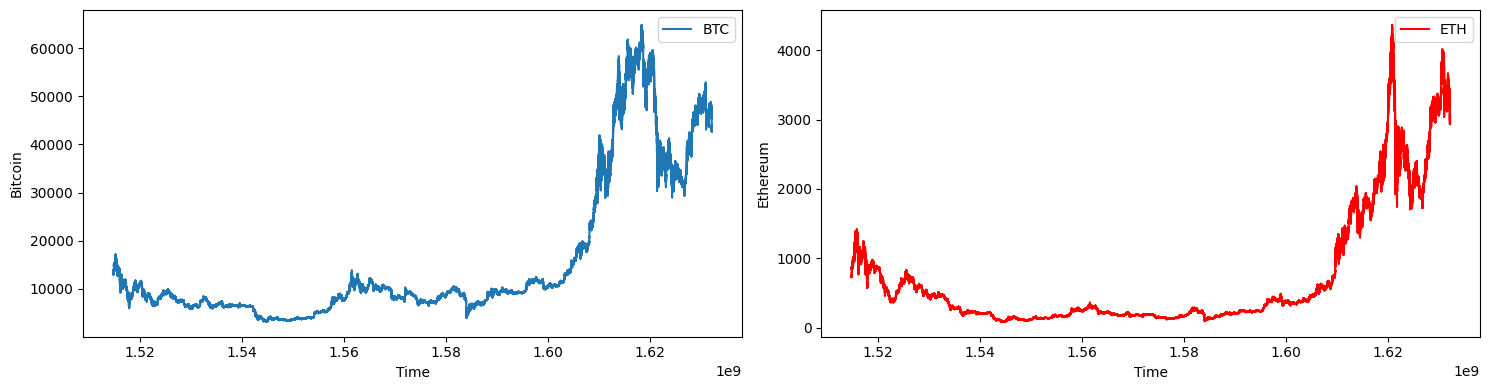

In [ ]:
import matplotlib.pyplot as plt


f = plt.figure(figsize=(15,4))


btc = btc.reindex(range(btc.index[0],btc.index[-1]+60,60),method='pad')

ax = f.add_subplot(121)
plt.plot(btc['Close'], label='BTC')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Bitcoin')

ax2 = f.add_subplot(122)
ax2.plot(eth['Close'], color='red', label='ETH')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Ethereum')

plt.tight_layout()
plt.show()

In [ ]:
btc = btc.reset_index()
btc['timestamp'] = pd.to_datetime(btc['timestamp'], unit='s')
new_df = btc[['timestamp', 'Target', 'Asset_ID']].rename(columns={'Target': 'target'})

In [ ]:
df = new_df.dropna(subset=['target'])
df

,timestamp,target,Asset_ID
0,2018-01-01 00:01:00,-0.014643,1
1,2018-01-01 00:02:00,-0.015037,1
2,2018-01-01 00:03:00,-0.010309,1
3,2018-01-01 00:04:00,-0.008999,1
4,2018-01-01 00:05:00,-0.008079,1
...,...,...,...
1956939,2021-09-20 23:40:00,0.002084,1
1956940,2021-09-20 23:41:00,0.003246,1
1956941,2021-09-20 23:42:00,0.003108,1
1956942,2021-09-20 23:43:00,0.002770,1


In [ ]:
labeled = full["Target"].notna()
timestamps = full.loc[labeled, "timestamp"].values
split_ts = np.quantile(timestamps, 0.90)

train_mask = labeled & (full["timestamp"] < split_ts)
val_mask   = labeled & (full["timestamp"] >= split_ts)

print(train_mask.sum(), val_mask.sum())

23401630 2600193


In [ ]:
pred_mask = full["Target"].isna()
print("to predict:", pred_mask.sum())

to predict: 753261


In [ ]:
full.columns
full.loc[pred_mask].head()
sample_sub.head()

,group_num,row_id,Target
0,0,0,0
1,0,1,0
2,0,2,0
3,0,3,0
4,0,4,0


In [ ]:
class MaskSeqDataset(Dataset):
    def __init__(self, df, mask, features, lookback=60, id_col="ID"):
        self.df = df
        self.mask = mask.values
        self.features = features
        self.lookback = lookback
        self.id_col = id_col

        self.X = df[features].values.astype(np.float32)
        self.asset = df["Asset_ID"].values.astype(np.int64)
        self.ids = df[id_col].values

        idx = np.where(self.mask)[0]
        ok_idx = []
        ok_ids = []
        for j in idx:
            start = j - lookback + 1
            if start < 0:
                continue
            if self.asset[start] != self.asset[j]:
                continue
            ok_idx.append(j)
            ok_ids.append(self.ids[j])

        self.idx = np.array(ok_idx, dtype=np.int64)
        self.ok_ids = np.array(ok_ids)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, k):
        j = self.idx[k]
        start = j - self.lookback + 1
        x = self.X[start:j+1]
        a = self.asset[j]
        return torch.from_numpy(x), torch.tensor(a), self.ok_ids[k]

In [ ]:
labeled = full["Target"].notna()


cut_ts = np.quantile(full.loc[labeled, "timestamp"].values, 0.6)

full_small = full[full["timestamp"] >= cut_ts].copy()
full_small = full_small.sort_values(["Asset_ID", "timestamp"]).reset_index(drop=True)

print("full_small:", full_small.shape)
print("Target NaNs:", full_small["Target"].isna().mean(), "count:", full_small["Target"].isna().sum())

full_small: (10452201, 11)
Target NaNs: 0.004924417354775324 count: 51471


In [ ]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values(["Asset_ID", "timestamp"])
    g = df.groupby("Asset_ID", group_keys=False)

    df["log_close"]  = np.log(df["Close"].replace(0, np.nan))
    df["log_vwap"]   = np.log(df["VWAP"].replace(0, np.nan))
    df["log_volume"] = np.log1p(df["Volume"].clip(lower=0))
    df["log_count"]  = np.log1p(df["Count"].clip(lower=0))


    df["logret_close"] = g["log_close"].diff()
    df["logret_vwap"]  = g["log_vwap"].diff()


    df["hl_range"] = (df["High"] - df["Low"]) / df["Open"].replace(0, np.nan)
    df["co_return"] = np.log(df["Close"].replace(0, np.nan) / df["Open"].replace(0, np.nan))

    df["vol_chg"]   = g["Volume"].pct_change()
    df["count_chg"] = g["Count"].pct_change()
    for lag in [1, 2, 3, 5]:
        df[f"lag_ret_{lag}"] = g["logret_vwap"].shift(lag)
        df[f"lag_volchg_{lag}"] = g["vol_chg"].shift(lag)
        df[f"lag_countchg_{lag}"] = g["count_chg"].shift(lag)

    for w in [5, 15, 60]:
        df[f"ret_mean_{w}"] = g["logret_vwap"].apply(lambda s: s.shift(1).rolling(w).mean())
        df[f"ret_std_{w}"]  = g["logret_vwap"].apply(lambda s: s.shift(1).rolling(w).std())
        df[f"vol_mean_{w}"] = g["Volume"].apply(lambda s: s.shift(1).rolling(w).mean())
        df[f"cnt_mean_{w}"] = g["Count"].apply(lambda s: s.shift(1).rolling(w).mean())

    seconds_in_day = 24 * 60 * 60
    tod = (df["timestamp"] % seconds_in_day) / seconds_in_day
    df["tod_sin"] = np.sin(2 * np.pi * tod)
    df["tod_cos"] = np.cos(2 * np.pi * tod)

    return df

In [ ]:
full_small = add_features(full_small)

In [ ]:
FEATURES = [
    "log_close","log_vwap","log_volume","log_count",
    "logret_close","logret_vwap","hl_range","co_return",
    "vol_chg","count_chg",
    "lag_ret_1","lag_ret_2","lag_ret_3","lag_ret_5",
    "lag_volchg_1","lag_volchg_2","lag_volchg_3","lag_volchg_5",
    "lag_countchg_1","lag_countchg_2","lag_countchg_3","lag_countchg_5",
    "ret_mean_5","ret_std_5","vol_mean_5","cnt_mean_5",
    "ret_mean_15","ret_std_15","vol_mean_15","cnt_mean_15",
    "ret_mean_60","ret_std_60","vol_mean_60","cnt_mean_60",
    "tod_sin","tod_cos",
]

In [ ]:
train_feats = full_small.loc[train_mask, FEATURES].astype(np.float32)
mu = train_feats.mean(axis=0)
sd = train_feats.std(axis=0).replace(0, 1.0)

full_small[FEATURES] = ((full_small[FEATURES].astype(np.float32) - mu) / sd).fillna(0.0)

In [ ]:
print(sample_sub.columns)
print(full_small.columns)

Index(['group_num', 'row_id', 'Target'], dtype='object')
Index(['timestamp', 'Asset_ID', 'Count', 'Open', 'High', 'Low', 'Close',
       'Volume', 'VWAP', 'Target', 'Weight', 'logret_close', 'logret_vwap',
       'hl_range', 'co_return', 'vol_chg', 'ret_mean_5', 'ret_std_5',
       'vol_mean_5', 'ret_mean_15', 'ret_std_15', 'vol_mean_15', 'ret_mean_60',
       'ret_std_60', 'vol_mean_60', 'tod_sin', 'tod_cos', 'log_close',
       'log_vwap', 'log_volume', 'log_count', 'count_chg', 'lag_ret_1',
       'lag_volchg_1', 'lag_countchg_1', 'lag_ret_2', 'lag_volchg_2',
       'lag_countchg_2', 'lag_ret_3', 'lag_volchg_3', 'lag_countchg_3',
       'lag_ret_5', 'lag_volchg_5', 'lag_countchg_5', 'cnt_mean_5',
       'cnt_mean_15', 'cnt_mean_60'],
      dtype='object')


In [ ]:
print(train_df.columns)
print(supp_df.columns)

Index(['timestamp', 'Asset_ID', 'Count', 'Open', 'High', 'Low', 'Close',
       'Volume', 'VWAP', 'Target'],
      dtype='object')
Index(['timestamp', 'Asset_ID', 'Count', 'Open', 'High', 'Low', 'Close',
       'Volume', 'VWAP', 'Target'],
      dtype='object')


In [ ]:
from collections import deque, defaultdict

In [ ]:
ROLL_WINS = [5, 15, 60]
LAGS = [1, 2, 3, 5]

In [ ]:
class AssetState:
    def __init__(self):
        self.prev_log_vwap = None
        self.prev_log_close = None
        self.prev_volume = None
        self.prev_count = None
        self.ret_hist = deque(maxlen=max(LAGS) + 60 + 5)
        self.volchg_hist = deque(maxlen=max(LAGS) + 60 + 5)
        self.countchg_hist = deque(maxlen=max(LAGS) + 60 + 5)
        self.seq = deque(maxlen=LOOKBACK)

states = defaultdict(AssetState)

In [ ]:
def safe_log(x):
    return np.log(x) if (x is not None and x > 0) else np.nan

def safe_log1p(x):
    return np.log1p(x) if (x is not None and x >= 0) else np.nan

def roll_mean_std(arr, w):
    if len(arr) < w:
        return np.nan, np.nan
    x = np.array(list(arr)[-w:], dtype=np.float32)
    return float(np.mean(x)), float(np.std(x, ddof=0))

def build_feature_row(row, st: AssetState):

    open_ = float(row["Open"])
    high_ = float(row["High"])
    low_  = float(row["Low"])
    close_= float(row["Close"])
    vol_  = float(row["Volume"])
    cnt_  = float(row["Count"])
    vwap_ = float(row["VWAP"])
    ts    = int(row["timestamp"])


    log_close = safe_log(close_)
    log_vwap  = safe_log(vwap_)
    log_volume = safe_log1p(max(vol_, 0.0))
    log_count  = safe_log1p(max(cnt_, 0.0))

    hl_range = (high_ - low_) / open_ if open_ != 0 else np.nan
    co_return = np.log(close_ / open_) if (open_ > 0 and close_ > 0) else np.nan

    cur_logret_vwap  = (log_vwap  - st.prev_log_vwap)  if (st.prev_log_vwap  is not None and np.isfinite(log_vwap))  else np.nan
    cur_logret_close = (log_close - st.prev_log_close) if (st.prev_log_close is not None and np.isfinite(log_close)) else np.nan

    cur_vol_chg = (vol_ / st.prev_volume - 1.0) if (st.prev_volume is not None and st.prev_volume != 0) else np.nan
    cur_count_chg = (cnt_ / st.prev_count - 1.0) if (st.prev_count is not None and st.prev_count != 0) else np.nan

    logret_close = cur_logret_close
    logret_vwap  = cur_logret_vwap
    vol_chg      = cur_vol_chg
    count_chg    = cur_count_chg


    def lag_from(hist, lag):
        if len(hist) < lag:
            return np.nan
        return list(hist)[-lag]

    lag_ret = {lag: lag_from(st.ret_hist, lag) for lag in LAGS}
    lag_vol = {lag: lag_from(st.volchg_hist, lag) for lag in LAGS}
    lag_cnt = {lag: lag_from(st.countchg_hist, lag) for lag in LAGS}

    roll = {}
    for w in ROLL_WINS:
        m, s = roll_mean_std(st.ret_hist, w)
        roll[f"ret_mean_{w}"] = m
        roll[f"ret_std_{w}"]  = s

        vm, _ = roll_mean_std(st.volchg_hist, w)
        cm, _ = roll_mean_std(st.countchg_hist, w)
        roll[f"vol_mean_{w}"] = vm
        roll[f"cnt_mean_{w}"] = cm


    seconds_in_day = 24 * 60 * 60
    tod = (ts % seconds_in_day) / seconds_in_day
    tod_sin = np.sin(2 * np.pi * tod)
    tod_cos = np.cos(2 * np.pi * tod)


    feat = {
        "log_close": log_close,
        "log_vwap": log_vwap,
        "log_volume": log_volume,
        "log_count": log_count,

        "logret_close": logret_close,
        "logret_vwap": logret_vwap,
        "hl_range": hl_range,
        "co_return": co_return,
        "vol_chg": vol_chg,
        "count_chg": count_chg,

        "tod_sin": tod_sin,
        "tod_cos": tod_cos,
    }

    for lag in LAGS:
        feat[f"lag_ret_{lag}"] = lag_ret[lag]
        feat[f"lag_volchg_{lag}"] = lag_vol[lag]
        feat[f"lag_countchg_{lag}"] = lag_cnt[lag]

    for w in ROLL_WINS:
        feat[f"ret_mean_{w}"] = roll[f"ret_mean_{w}"]
        feat[f"ret_std_{w}"]  = roll[f"ret_std_{w}"]
        feat[f"vol_mean_{w}"] = roll[f"vol_mean_{w}"]
        feat[f"cnt_mean_{w}"] = roll[f"cnt_mean_{w}"]

    if np.isfinite(cur_logret_vwap):
        st.ret_hist.append(cur_logret_vwap)
    if np.isfinite(cur_vol_chg):
        st.volchg_hist.append(cur_vol_chg)
    if np.isfinite(cur_count_chg):
        st.countchg_hist.append(cur_count_chg)

    st.prev_log_vwap = log_vwap if np.isfinite(log_vwap) else st.prev_log_vwap
    st.prev_log_close = log_close if np.isfinite(log_close) else st.prev_log_close
    st.prev_volume = vol_
    st.prev_count = cnt_

    return feat

In [ ]:
class PredSeqDataset(Dataset):
    def __init__(self, df, mask, features, lookback=60):
        self.df = df
        self.features = features
        self.lookback = lookback

        self.X = df[features].values.astype(np.float32)
        self.asset = df["Asset_ID"].values.astype(np.int64)

        idx = np.where(mask.values)[0]
        ok = []
        for j in idx:
            start = j - lookback + 1
            if start < 0:
                continue
            if self.asset[start] != self.asset[j]:
                continue
            ok.append(j)
        self.idx = np.array(ok, dtype=np.int64)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, k):
        j = self.idx[k]
        start = j - self.lookback + 1
        x = self.X[start:j+1]
        a = self.asset[j]
        return torch.from_numpy(x), torch.tensor(a), j

In [ ]:
full_small = full_small.reset_index(drop=True)

train_mask = full_small["Target"].notna() & (full_small["timestamp"] < split_ts)
val_mask   = full_small["Target"].notna() & (full_small["timestamp"] >= split_ts)
pred_mask  = full_small["Target"].isna()

print(len(full_small), len(train_mask), len(val_mask), len(pred_mask))

10452201 10452201 10452201 10452201


In [ ]:
pred_ds = PredSeqDataset(full_small, pred_mask, FEATURES, lookback=LOOKBACK)

In [ ]:
pred_loader = DataLoader(
    pred_ds,
    batch_size=2048,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [ ]:
class CryptoLSTM(nn.Module):
    def __init__(
        self,
        n_assets: int,
        n_features: int,
        emb_dim: int = 16,
        hidden: int = 256,
        num_layers: int = 2,
        dropout: float = 0.2,
        use_attention_pool: bool = False,
    ):
        super().__init__()
        self.use_attention_pool = use_attention_pool

        self.asset_emb = nn.Embedding(n_assets, emb_dim)

        self.lstm = nn.LSTM(
            input_size=n_features + emb_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )

        if use_attention_pool:
            self.attn = nn.Sequential(
                nn.Linear(hidden, hidden),
                nn.Tanh(),
                nn.Linear(hidden, 1),
            )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x: torch.Tensor, asset_id: torch.Tensor) -> torch.Tensor:

        b, l, f = x.shape

        e = self.asset_emb(asset_id)
        e = e.unsqueeze(1).expand(b, l, e.size(-1))
        z = torch.cat([x, e], dim=-1)

        out, _ = self.lstm(z)

        if self.use_attention_pool:
            w = self.attn(out)
            w = torch.softmax(w, dim=1)
            h = (out * w).sum(dim=1)
        else:
            h = out[:, -1, :]

        y = self.head(h).squeeze(-1)
        return y

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_assets = int(full_small["Asset_ID"].max() + 1)
n_features = len(FEATURES)

model = CryptoLSTM(
    n_assets=n_assets,
    n_features=n_features,
    emb_dim=16,
    hidden=256,
    num_layers=2,
    dropout=0.2,
    use_attention_pool=False,
).to(device)

In [ ]:
model.eval()

all_j = []
all_p = []

with torch.no_grad():
    for x, a, j in pred_loader:
        x = x.to(device)
        a = a.to(device)
        p = model(x, a).detach().cpu().numpy().astype(np.float32)
        all_j.append(j.numpy())
        all_p.append(p)

all_j = np.concatenate(all_j)
all_p = np.concatenate(all_p)

print("got preds:", all_p.shape, "for indices:", all_j.shape)

got preds: (51463,) for indices: (51463,)


In [ ]:
pred_full = np.full(len(full_small), np.nan, dtype=np.float32)
pred_full[all_j] = all_p


print("all predicted indices are NaN targets:", bool(pred_mask.iloc[all_j].all()))

all predicted indices are NaN targets: True


In [ ]:
pred_out = full_small.loc[all_j, ["timestamp", "Asset_ID"]].copy()
pred_out["Target_pred"] = all_p

pred_out.to_csv("predictions_nan_target.csv", index=False)
pred_out.head()

,timestamp,Asset_ID,Target_pred
40303,1600446420,0,-0.285394
40304,1600446480,0,-0.287087
40305,1600446540,0,-0.295769
40306,1600446600,0,-0.300874
40307,1600446660,0,-0.294999


In [ ]:
full_shuffled = full_small.copy()

for asset in full_shuffled["Asset_ID"].unique():
    mask = full_shuffled["Asset_ID"] == asset
    full_shuffled.loc[mask, "Target"] = np.random.permutation(
        full_shuffled.loc[mask, "Target"].values
    )

corr = pearsonr(pred_full[~np.isnan(pred_full)],
                full_shuffled["Target"][~np.isnan(pred_full)])[0]

print(corr)

In [ ]:
asset = 1
tmp = full_small[full_small["Asset_ID"] == asset]

print(tmp[["timestamp", "Target"]].head(10))

In [ ]:
full_small["baseline"] = full_small.groupby("Asset_ID")["Close"].pct_change()

mask = ~np.isnan(pred_full)

from scipy.stats import pearsonr
corr_model = pearsonr(pred_full[mask], full_small["Target"][mask])[0]
corr_base = pearsonr(full_small["baseline"][mask].fillna(0), full_small["Target"][mask])[0]

print("Model corr:", corr_model)
print("Baseline corr:", corr_base)

In [ ]:
cutoff = full_small["timestamp"].quantile(0.8)

train_mask = full_small["timestamp"] < cutoff
val_mask = full_small["timestamp"] >= cutoff

In [ ]:
cutoff = full_small["timestamp"].quantile(0.8)

train_mask = full_small["timestamp"] < cutoff
val_mask = full_small["timestamp"] >= cutoff

In [ ]:
def eval_corr(model, loader, device):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            out = model(xb).detach().cpu().numpy().reshape(-1)
            preds.append(out)
            trues.append(yb.detach().cpu().numpy().reshape(-1))
    p = np.concatenate(preds)
    y = np.concatenate(trues)

    if np.std(p) < 1e-8 or np.std(y) < 1e-8:
        return 0.0
    return float(np.corrcoef(p, y)[0, 1])